## Librerias

In [2]:
import pandas as pd
#import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
#from rapidfuzz import process, fuzz
import unicodedata
import re
#import folium


## Funciones Auxiliares

In [3]:
## Graficas de variables cualitativas con porcentaje
def plot_categorical_summary(df, columna):
    # Convertir a string para evitar errores de tipo
    datos = df[columna].astype(str)

    # Calcular porcentajes
    porcentaje = datos.value_counts(normalize=True, dropna=False) * 100
    categorias = porcentaje.index
    valores = porcentaje.values

    # Gráfico
    plt.figure(figsize=(8, 4))
    barras = plt.bar(categorias, valores, color='skyblue', edgecolor='black')

    for i, bar in enumerate(barras):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{valores[i]:.1f}%',
                 ha='center', fontsize=10)

    plt.title(columna)
    plt.ylabel('Porcentaje (%)')
    plt.xlabel('Categorías')
    plt.xticks(rotation=45)
    plt.ylim(0, max(valores) + 10)
    plt.tight_layout()
    plt.show()

In [4]:
df = pd.read_excel('../data/CARACTERIZACION_1.xlsx')
df.head()

,TIPO_DOCUMENTO,DOCUMENTO,GENERO,NOMBRE,UNIDAD,PENSUM,FECHA_ACTUALIZACION,ESTADO SOCIODEMOGRAFICO,ESTADO VULNERABILIDAD,ESTADO CONDICIONES DE SALUD,...,TRATAMIENTO_MEDICO,FECHA_DIAGNOSTICO,FUMA,ESTA_EMBARAZO,CONSUME_ALCOHOL,PESO,ESTATURA,CONSUME_SUSTANCIAS_PSICOACTIVAS,TIENE_TITULO,OTROS_ESTUDIOS
0,CC,1069734259,M,JEFERSSON GIOVANNY PICO ACOSTA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,112,190,NaN,NaN,NaN
1,CC,1069735295,F,MAYERLI YAQUELIN PARRA MORA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CC,1069734073,F,YEIMY LORENA PIÑEROS GUTIERREZ,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,2023-06-01 11:38:27.000,INFORMACIÓN SOCIODEMOGRÁFICA: aprobado,VULNERABILIDAD: pendiente de revision,CONDICIONES DE SALUD: pendiente de revision,...,Si,2007-05-10 00:00:00,Nunca,No,Nunca,52,1.60,Nunca,NaN,NaN
3,CC,1069735681,F,CLAUDIA LORENA BOLIVAR TUNAROSA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CC,1069737604,M,KEVIN DAVID CRUZ MELO,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,2023-06-24 12:19:26.000,INFORMACIÓN SOCIODEMOGRÁFICA: aprobado,VULNERABILIDAD: pendiente de revision,CONDICIONES DE SALUD: pendiente de revision,...,No,NaN,Nunca,No,Nunca,104,1.78,Nunca,NaN,NaN


In [5]:
df_2 = pd.read_excel('../data/desempeño_areas_formacion.xlsx')
df_2.head()

,PERIODO,FACULTAD,UNIDAD,PENSUM,DOCUMENTO,NOMBRES,MATRICULA_ACTUAL,SITUACION_ACTUAL,CATEGORIA_ACTUAL,CIENCIAS BÁSICAS,CIENCIAS BÁSICAS DE INGENIERÍA,INGENIERÍA APLICADA,INSTITUCIONAL,TOTAL_BAJO_RENDIMIENTO_REA,DESERTA
0,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1000136072,FORERO HERRERA TANIA NICKOLL,SIN MATRICULA,ACTIVO,CONTINUIDAD ACADEMICA - EGRESADO,3.553846,3.956154,3.951915,3.897200,2,0
1,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1000320087,MESA BLANCO LEONARDO JUAN,SIN MATRICULA,ACTIVO,ANTIGUO,3.310833,3.297368,3.661538,3.761000,9,0
2,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1000592838,BAUTISTA DIAZ DANIEL EDUARDO,SIN MATRICULA,ACTIVO,CONTINUIDAD ACADEMICA - EGRESADO,3.475000,3.625714,3.960278,3.890833,6,0
3,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1001346777,SUAREZ HEREDIA JUAN SEBASTIAN,SIN MATRICULA,EXCLUIDO BAJO RENDIMIENTO,ANTIGUO,3.171429,2.900000,3.100000,3.000000,7,1
4,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1003515700,ESCOBAR VASQUEZ JENIFFER DAYANA,SIN MATRICULA,EXCLUIDO BAJO RENDIMIENTO,ANTIGUO,3.328571,2.623529,3.900000,3.485714,10,1


In [6]:
# Obtener los valores únicos de cada columna
documentos_df = set(df['DOCUMENTO'].unique())
documentos_df2 = set(df_2['DOCUMENTO'].unique())

# Calcular la intersección
documentos_comunes = documentos_df.intersection(documentos_df2)

# Mostrar la cantidad de documentos que coinciden
print(f"Número de DOCUMENTO que coinciden: {len(documentos_comunes)}")


Número de DOCUMENTO que coinciden: 767


In [7]:
df_caracterizacion = df[df['DOCUMENTO'].isin(documentos_comunes)]

In [9]:
df_caracterizacion.head(5)

,TIPO_DOCUMENTO,DOCUMENTO,GENERO,NOMBRE,UNIDAD,PENSUM,FECHA_ACTUALIZACION,ESTADO SOCIODEMOGRAFICO,ESTADO VULNERABILIDAD,ESTADO CONDICIONES DE SALUD,...,TRATAMIENTO_MEDICO,FECHA_DIAGNOSTICO,FUMA,ESTA_EMBARAZO,CONSUME_ALCOHOL,PESO,ESTATURA,CONSUME_SUSTANCIAS_PSICOACTIVAS,TIENE_TITULO,OTROS_ESTUDIOS
4,CC,1069737604,M,KEVIN DAVID CRUZ MELO,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,2023-06-24 12:19:26.000,INFORMACIÓN SOCIODEMOGRÁFICA: aprobado,VULNERABILIDAD: pendiente de revision,CONDICIONES DE SALUD: pendiente de revision,...,No,NaN,Nunca,No,Nunca,104,1.78,Nunca,NaN,NaN
9,CC,1026290752,M,WILLIAM ESTEBAN BRICEÑO CASTRILLON,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,2023-06-23 18:49:28.000,INFORMACIÓN SOCIODEMOGRÁFICA: aprobado,VULNERABILIDAD: pendiente de revision,CONDICIONES DE SALUD: pendiente de revision,...,No,NaN,Nunca,No,Una vez al mes,87,1.75,Nunca,NaN,NaN
12,CC,1069750774,M,HARVEY GUSTAVO VARGAS GUIZA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,No,NaN,Nunca,No,Nunca,87,1.74,Nunca,NaN,NaN
21,CC,1069747785,M,JUAN CAMILO VANEGAS FISCAL,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,No,NaN,Nunca,No,Una vez al mes,80,170,Nunca,NaN,NaN
30,CC,1069760977,M,EDGAR ORLANDO ROMERO MORA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,No,NaN,Nunca,No,Una vez al mes,68,1.72,Nunca,NaN,NaN


In [10]:
df_caracterizacion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 835 entries, 4 to 2375
Data columns (total 85 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   TIPO_DOCUMENTO                      835 non-null    object 
 1   DOCUMENTO                           835 non-null    int64  
 2   GENERO                              835 non-null    object 
 3   NOMBRE                              835 non-null    object 
 4   UNIDAD                              835 non-null    object 
 5   PENSUM                              835 non-null    object 
 6   FECHA_ACTUALIZACION                 500 non-null    object 
 7   ESTADO SOCIODEMOGRAFICO             500 non-null    object 
 8   ESTADO VULNERABILIDAD               500 non-null    object 
 9   ESTADO CONDICIONES DE SALUD         500 non-null    object 
 10  UBICACION_SEMESTRAL                 835 non-null    int64  
 11  CELULAR                             821 non-null 

In [11]:
df_caracterizacion.isnull().sum()/len(df_caracterizacion)*100

TIPO_DOCUMENTO                      0.000000
DOCUMENTO                           0.000000
GENERO                              0.000000
NOMBRE                              0.000000
UNIDAD                              0.000000
                                     ...    
PESO                                0.479042
ESTATURA                            0.479042
CONSUME_SUSTANCIAS_PSICOACTIVAS     4.311377
TIENE_TITULO                       49.820359
OTROS_ESTUDIOS                     49.820359
Length: 85, dtype: float64

## ELIMINACIÓN DE VARIABLES
A continuación se dispone a eliminar aquellas variables que en principios no generan información valiosa para el modelo ya sea por que son ID´s, nombre, variables que toman siempre el mismo valor entre otras. Es de resaltar que atravez del cuadernillo se iran elimnando otras variables que al analizarlas no hacen sentido o se unen con otra variable.

1.   UNIDAD = Siempre toma el mismo valor
2.   PENSUM = Siempre toma el mismo valor
3.   NOMBRE = No es una variable adecuada para el modelo
4.   FECHA_ACTUALIZACIÓN = No es una variable adecuada para el modelo
5.   ESTADO SOCIODEMOGRAFICO = Muchos datos faltantes y lo valores que toma es un estado de revisión
6.   ESTADO VULNERABILIDAD = Muchos datos faltantes y lo valores que toma es un estado de revisión
7.   ESTADO CONDICIONES DE SALUD = Muchos datos faltantes y lo valores que toma es un estado de revisión
8. CELULAR = No es una variable adecuada para el modelo
9. EMAIL_INSTITUCIONAL = No es una variable adecuada para el modelo
10. NOMBRE_CONTACTO_EMERGENCIA = No es una variable adecuada para el modelo
11. CELULAR_CONTACTO_EMERGENCIA = No es una variable adecuada para el modelo
12. PARENTESCO_CONTACTO_EMERGENCIA = No es una variable adecuada para el modelo
13. ARL = Tiene muchos valores vacios
14. DISCAPACIDAD_AUDITIVA_CASTELLANO = Muchos datos faltantes y el valor que toma no es determinante
15. DISCAPACIDAD_AUDITIVA_LENGUASENAS = Muchos datos faltantes y el valor que toma no es determinante
16. AYUDA_AUDITIVA = Muchos datos faltantes y el valor que toma no es determinante
17. DISCAPACIDAD_VISUAL_BAJAVISION = Muchos datos faltantes y el valor que toma no es determinante
18. DISCAPACIDAD_VISUAL_CEGUERA = Muchos datos faltantes y el valor que toma no es determinante
19. FECHA_DIAGNOSTICO = No es una variable adecuada para el modelo

In [12]:
Eliminar = ["UNIDAD", "PENSUM", "NOMBRE", "ESTADO SOCIODEMOGRAFICO", "ESTADO VULNERABILIDAD", "ESTADO CONDICIONES DE SALUD",
            "CELULAR", "EMAIL_INSTITUCIONAL", "NOMBRE_CONTACTO_EMERGENCIA", "CELULAR_CONTACTO_EMERGENCIA", "PARENTESCO_CONTACTO_EMERGENCIA", "ARL",
            "DISCAPACIDAD_AUDITIVA_CASTELLANO", "DISCAPACIDAD_AUDITIVA_LENGUASENAS", "AYUDA_AUDITIVA", "DISCAPACIDAD_VISUAL_BAJAVISION", "DISCAPACIDAD_VISUAL_CEGUERA",
            "FECHA_DIAGNOSTICO"]

df_caracterizacion.drop(Eliminar, axis=1, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_24440\2018384542.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion.drop(Eliminar, axis=1, inplace=True)


In [13]:
df_caracterizacion

,TIPO_DOCUMENTO,DOCUMENTO,GENERO,FECHA_ACTUALIZACION,UBICACION_SEMESTRAL,ORIENTACION_SEXUAL,MEDIO_TRANSPORTE,FRECUENCIA_TRANSPORTE,HORARIO_INICIO_TRANSPORTE,HORARIO_FIN_TRANSPORTE,...,ENFERMEDADES_CRONICAS,TRATAMIENTO_MEDICO,FUMA,ESTA_EMBARAZO,CONSUME_ALCOHOL,PESO,ESTATURA,CONSUME_SUSTANCIAS_PSICOACTIVAS,TIENE_TITULO,OTROS_ESTUDIOS
4,CC,1069737604,M,2023-06-24 12:19:26.000,2,Heterosexualidad,Bicicleta,4 veces al dia,06:30:00,18:00:00,...,ul,No,Nunca,No,Nunca,104,1.78,Nunca,NaN,NaN
9,CC,1026290752,M,2023-06-23 18:49:28.000,9,Heterosexualidad,Moto,1 vez al dia,12:00:00,22:00:00,...,ul,No,Nunca,No,Una vez al mes,87,1.75,Nunca,NaN,NaN
12,CC,1069750774,M,NaN,9,NaN,A pie,1 vez al dia,05:30:00,18:00:00,...,NaN,No,Nunca,No,Nunca,87,1.74,Nunca,NaN,NaN
21,CC,1069747785,M,NaN,5,NaN,A pie,mas de 5 veces al dia,06:00:00,21:00:00,...,ul,No,Nunca,No,Una vez al mes,80,170,Nunca,NaN,NaN
30,CC,1069760977,M,NaN,9,Heterosexualidad,A pie,2 veces al dia,06:00:00,21:00:00,...,ul,No,Nunca,No,Una vez al mes,68,1.72,Nunca,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113,CC,11202693,M,2023-06-08 11:35:46.000,6,Heterosexualidad,Servicio público,2 veces al dia,06:00:00,20:00:00,...,ul,No,Nunca,No,Nunca,90,174,Nunca,NaN,NaN
1588,CC,1023970909,M,2023-06-20 13:26:05.000,0,Heterosexualidad,Servicio público,1 vez al dia,06:30:00,17:30:00,...,ul,No,Nunca,No,Una vez al mes,64,1.75,Nunca,NaN,NaN
1701,CC,1007664640,M,NaN,2,Heterosexualidad,Servicio público,1 vez al dia,06:30:00,17:00:00,...,ul,No,Nunca,No,Nunca,75,175,Nunca,NaN,NaN
2015,CC,1000693735,F,2024-07-04 16:11:17.000,0,Heterosexualidad,Servicio público,2 veces al dia,11:30:00,18:30:00,...,ul,No,Nunca,No,Una vez al mes,85,1.67,Nunca,NaN,NaN


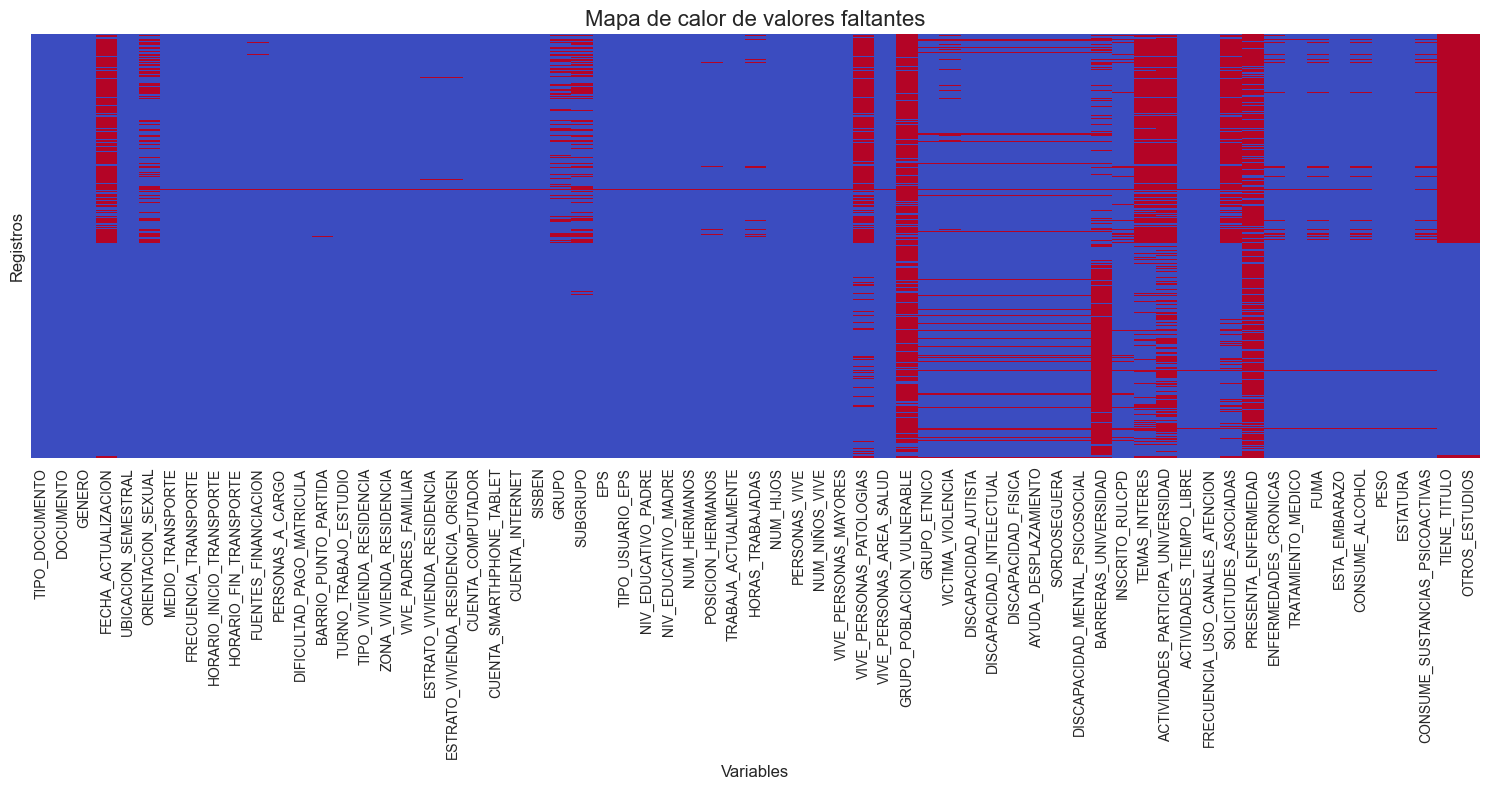

In [14]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_caracterizacion.isnull(),
            cbar=False,
            cmap='coolwarm',
            yticklabels=False)

plt.title("Mapa de calor de valores faltantes", fontsize=16)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Registros", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Se revisara aquellas filas que contiene menos 40% de valores faltantes para eliminarlas ya que si se imputa por columna ese registro sería artificial ya que seria el resultado de solo imputaciones.

In [16]:
# Calcular el porcentaje de valores faltantes por fila
porcentaje_faltantes = df_caracterizacion.isnull().mean(axis=1)

# Identificar las filas con más del 40% de valores faltantes
filas_con_mas_de_40 = df_caracterizacion[porcentaje_faltantes > 0.4]


In [17]:
filas_con_mas_de_40

,TIPO_DOCUMENTO,DOCUMENTO,GENERO,FECHA_ACTUALIZACION,UBICACION_SEMESTRAL,ORIENTACION_SEXUAL,MEDIO_TRANSPORTE,FRECUENCIA_TRANSPORTE,HORARIO_INICIO_TRANSPORTE,HORARIO_FIN_TRANSPORTE,...,ENFERMEDADES_CRONICAS,TRATAMIENTO_MEDICO,FUMA,ESTA_EMBARAZO,CONSUME_ALCOHOL,PESO,ESTATURA,CONSUME_SUSTANCIAS_PSICOACTIVAS,TIENE_TITULO,OTROS_ESTUDIOS
54,CC,1073718238,M,NaN,9,NaN,Servicio público,4 veces al dia,05:00:00,21:00:00,...,NaN,NaN,NaN,No,NaN,68,184,NaN,NaN,NaN
145,CC,1069767713,F,NaN,9,NaN,A pie,1 vez al dia,07:30:00,17:00:00,...,NaN,NaN,NaN,No,NaN,63,1.64,NaN,NaN,NaN
326,CC,1000589613,M,2024-06-28 14:00:29.000,9,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438,CC,1069763449,M,NaN,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,60,180,NaN,NaN,NaN
479,CC,1006692896,M,NaN,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,65,1.63,NaN,NaN,NaN


In [18]:
df_caracterizacion.drop(filas_con_mas_de_40.index, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_24440\18075017.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion.drop(filas_con_mas_de_40.index, inplace=True)


Se escoje un 40% por criterio arbitrario como el fin es poder modelar la deserción si se amplia el umbral se perderian muchos registros.

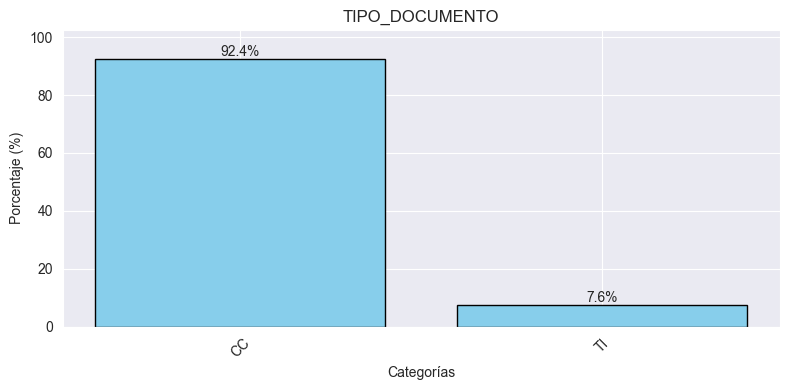

In [19]:
plot_categorical_summary(df_caracterizacion, 'TIPO_DOCUMENTO')

Esta variable se elimina por que se considera con poco poder predictivo.

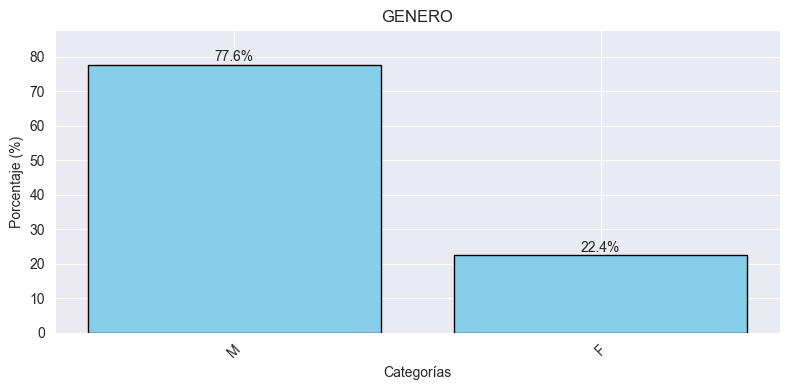

In [20]:
plot_categorical_summary(df_caracterizacion, 'GENERO')


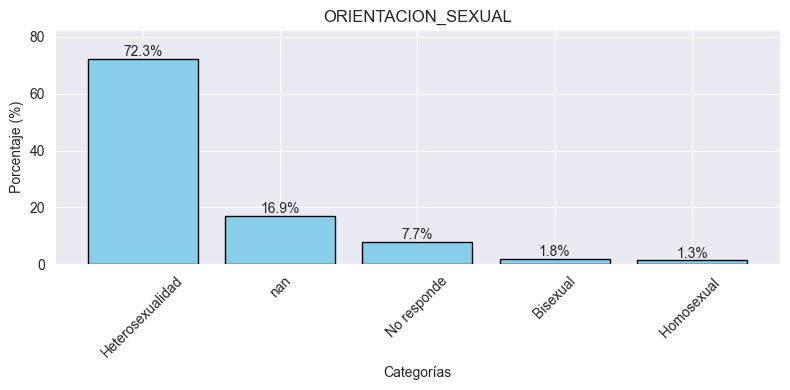

In [21]:
plot_categorical_summary(df_caracterizacion, 'ORIENTACION_SEXUAL')


Se considera una variable importante sin embargo se realizará una recategorización de los valores para capturar mejorar la información que ofrece la variable. Por otro lado, puede suceder que la decisión de "no responder" este correlacionado por una percepción de estigmatización o desconfianza institiucional o falta de compromiso con la encuesta, sin embargo, se mantiene

In [23]:
df_caracterizacion['ORIENTACION_SEXUAL'] = df_caracterizacion['ORIENTACION_SEXUAL'].fillna('No responde')
def agrupar_orientacion(valor):
    if valor in ['Homosexual', 'Bisexual']:
        return 'Diversa'
    elif valor == 'Heterosexualidad':
        return 'Heterosexual'
    else:
        return 'No responde'

df_caracterizacion['ORIENTACION_CAT'] = df_caracterizacion['ORIENTACION_SEXUAL'].apply(agrupar_orientacion)

C:\Users\User\AppData\Local\Temp\ipykernel_24440\1782198930.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['ORIENTACION_SEXUAL'] = df_caracterizacion['ORIENTACION_SEXUAL'].fillna('No responde')
C:\Users\User\AppData\Local\Temp\ipykernel_24440\1782198930.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['ORIENTACION_CAT'] = df_caracterizacion['ORIENTACION_SEXUAL'].apply(agrupar_orientacion)


In [24]:
df_caracterizacion['ORIENTACION_CAT'].value_counts()

ORIENTACION_CAT
Heterosexual    600
No responde     215
Diversa          15
Name: count, dtype: int64

In [25]:
df_caracterizacion["MEDIO_TRANSPORTE"].value_counts()

MEDIO_TRANSPORTE
Servicio público    393
A pie               369
Bicicleta            33
Moto                 26
Vehículo propio       7
,                     2
Name: count, dtype: int64

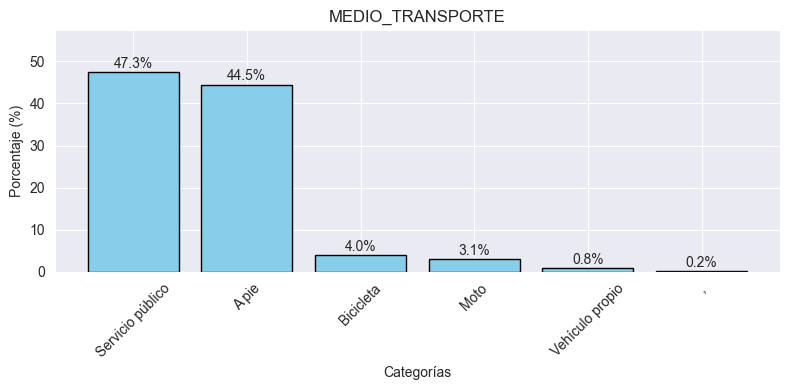

In [26]:
plot_categorical_summary(df_caracterizacion, 'MEDIO_TRANSPORTE')

Se recategoriza algunos valores con el fin de simplificar y mantener valor predictivo

In [27]:
# 1. Reemplazar categorías específicas
df_caracterizacion['MEDIO_TRANSPORTE'] = df_caracterizacion['MEDIO_TRANSPORTE'].replace({
    'Moto': 'Vehículo motorizado',
    'Vehículo propio': 'Vehículo motorizado',
    ',': 'A pie'  # coma suelta como categoría inválida
})

# 2. Reemplazar NaN por 'A pie'
df_caracterizacion['MEDIO_TRANSPORTE'] = df_caracterizacion['MEDIO_TRANSPORTE'].fillna('A pie')

C:\Users\User\AppData\Local\Temp\ipykernel_24440\2865197349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['MEDIO_TRANSPORTE'] = df_caracterizacion['MEDIO_TRANSPORTE'].replace({
C:\Users\User\AppData\Local\Temp\ipykernel_24440\2865197349.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['MEDIO_TRANSPORTE'] = df_caracterizacion['MEDIO_TRANSPORTE'].fillna('A pie')


In [28]:
df_caracterizacion['MEDIO_TRANSPORTE'].value_counts()

MEDIO_TRANSPORTE
Servicio público       393
A pie                  371
Vehículo motorizado     33
Bicicleta               33
Name: count, dtype: int64

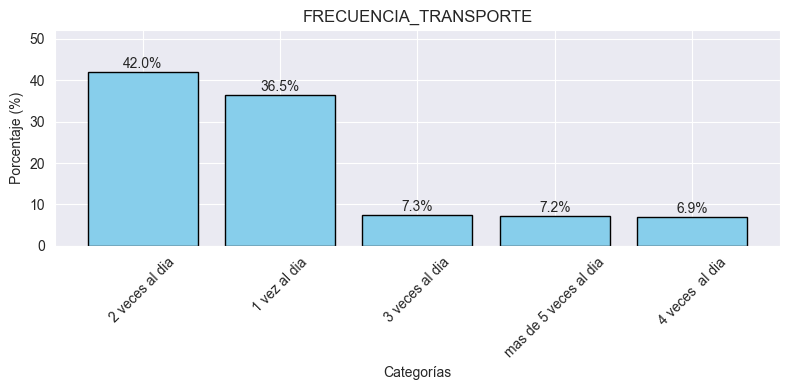

In [29]:
plot_categorical_summary(df_caracterizacion, 'FRECUENCIA_TRANSPORTE')


Se va recategorizar entendiendo que alguna categorias tienen poca representación lo que introduce ruido y sparsity para modelos predictivos

In [30]:
moda = df['FRECUENCIA_TRANSPORTE'].mode()[0]
df['FRECUENCIA_TRANSPORTE'] = df['FRECUENCIA_TRANSPORTE'].fillna(moda)

In [31]:
# Paso 2: Función para recategorizar la frecuencia de transporte
def recategorizar_frecuencia(valor):
    if valor in ['1 vez al día', '2 veces al día']:
        return 'Baja frecuencia'
    elif valor in ['3 veces al día', '4 veces al día', 'mas de 5 veces al día']:
        return 'Alta frecuencia'
    else:
        return 'Otro'  # Por si hay valores inesperados

# Paso 3: Aplicar la recategorización
df['FRECUENCIA_TRANSPORTE'] = df['FRECUENCIA_TRANSPORTE'].apply(recategorizar_frecuencia)

In [32]:
df_caracterizacion['FRECUENCIA_TRANSPORTE'].value_counts()

FRECUENCIA_TRANSPORTE
2 veces al dia           349
1 vez al dia             303
3 veces al dia            61
mas de 5 veces al dia     60
4 veces  al dia           57
Name: count, dtype: int64

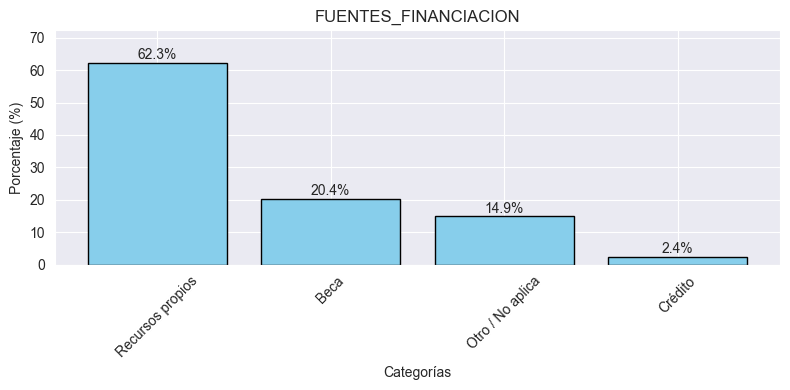

In [74]:
plot_categorical_summary(df_caracterizacion, 'FUENTES_FINANCIACION')

In [34]:
df_caracterizacion[ 'FUENTES_FINANCIACION'].value_counts()

FUENTES_FINANCIACION
Recursos propios o familiares                                                     514
No aplica                                                                          68
ul                                                                                 46
Generación E                                                                       40
Joven en acción- Recursos propios o familiares                                     36
Becas                                                                              24
Joven en acción                                                                    19
Joven en acción- Generación E                                                      17
Crédito bancario                                                                    9
Recursos propios o familiares- Crédito bancario                                     9
Becas- Recursos propios o familiares                                                7
Recursos propios o familiares- Ge

Se considera una recategorización de los valores de esta variable existe mucho ruido pero se considera importante para el desarrollo del modelo

In [35]:
def recategorizar_fuente(valor):
    valor = str(valor).lower()

    if any(palabra in valor for palabra in ['beca', 'generación e', 'joven en acción']):
        return 'Beca'
    elif any(palabra in valor for palabra in ['crédito', 'icetex']):
        return 'Crédito'
    elif any(palabra in valor for palabra in ['recurso', 'familiar']):
        return 'Recursos propios'
    elif valor.strip() in ['ul', '0', 'nan', 'no aplica', '']:
        return 'Otro / No aplica'
    else:
        return 'Otro / No aplica'  # para cualquier valor inesperado


In [36]:
df_caracterizacion['FUENTES_FINANCIACION'] = df_caracterizacion['FUENTES_FINANCIACION'].apply(recategorizar_fuente)
print(df_caracterizacion['FUENTES_FINANCIACION'].value_counts())

FUENTES_FINANCIACION
Recursos propios    517
Beca                169
Otro / No aplica    124
Crédito              20
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_24440\3368156425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['FUENTES_FINANCIACION'] = df_caracterizacion['FUENTES_FINANCIACION'].apply(recategorizar_fuente)


In [37]:
df_caracterizacion['BARRIO_PUNTO_PARTIDA'].value_counts(dropna=False).to_dict()

{'Balmoral': 37,
 'centro': 19,
 'ebenezer': 19,
 'Pekin': 15,
 'Fusacatan': 12,
 'Cedritos': 11,
 'arbelaez': 10,
 'Aires del quinini': 8,
 'Santander': 7,
 'Coburgo': 7,
 'pekin': 7,
 'Gaitan ': 7,
 'San Antonio': 6,
 'Emilio Sierra': 6,
 'Gaitan': 6,
 'los robles': 6,
 'gran colombia': 6,
 'la florida': 6,
 ' bonanza ': 6,
 'las delicias': 6,
 'la pampa': 5,
 'San Fernando': 5,
 'fusacatan': 5,
 'Macarena': 5,
 'Maiz Amarillo': 5,
 'villa natalia': 5,
 'gaitan': 5,
 'Luxemburgo': 4,
 'Bonet': 4,
 'Sauces': 4,
 'Marsella': 4,
 'PRADOS DE ALTAGRACIA': 4,
 'El vergel': 4,
 'Pablo bello': 4,
 'Aguabonita-Silvania': 4,
 'La independencia': 4,
 'Comuneros': 4,
 'Santa Barbara': 4,
 'Pardo leal': 4,
 'El eden': 4,
 'Olaya': 4,
 'GAITAN': 4,
 'Chinauta': 3,
 'CAMINO REAL': 3,
 'altos de pekin': 3,
 'pardo leal': 3,
 'mirador de san luis': 3,
 'silvania': 3,
 'NINGUNO': 3,
 'Nuevo Balmoral': 3,
 'Antonio Nariño ': 3,
 'autopista ': 3,
 'Bellavista': 3,
 'marsella': 3,
 'Camino real': 3,
 'Fu

In [38]:
df_caracterizacion['BARRIO_PUNTO_PARTIDA'] = (
    df_caracterizacion['BARRIO_PUNTO_PARTIDA']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)

C:\Users\User\AppData\Local\Temp\ipykernel_24440\4163240614.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['BARRIO_PUNTO_PARTIDA'] = (


In [40]:
comunas_fusagasuga = {
    'Comuna Centro': [
        'santander', 'emilio sierra', 'centro', 'olaya', 'luxemburgo', 'potosí', 'barrio centro', 'fusagasuga', 'toluca', 'cipreces', 'akropolis',
        'las palmas', 'ciudadela cootransfusa', 'anita', 'san rafael', 'conjunto lucitania', 'la florida', 'coontradecun', 'la plaza', 'conjunto santa helena'
    ],
    'Comuna Norte': [
        'el progreso', 'josé antonio galán', 'la cabaña', 'nueva esperanza', 'la esmeralda',
        'villa armerita', 'san antonio', 'gaitán i', 'gaitán ii', 'gaitan ii', 'gaitan 2etapa','la independencia', 'gaitan'
        'gaitán', 'galan', 'galan bajo', 'gaitan', 'gaitán', 'galan bajo',
        'el edén', 'villa natalia', 'la florida', 'los andes', 'santa librada',
        'mi tesoro', 'villa rosalía', 'el rosal', 'villas de san diego i', 'villas de san diego ii',
        'monte verde', 'los fundadores', 'la palma', 'carlos lleras', 'porvenir la salle', 'el lucero', 'la palma 2', 'la palma 3',
        'la clarita', 'villa patricia', 'conjunto montearroyo', 'bosques de oriente', 'porvenir'
    ],
    'Comuna Occidental': [
        'san mateo', 'manila', 'santa anita', 'san jorge', 'marsella', 'comboy', 'mandalay',
        'nuevo balmoral', 'el caney', 'fontanar', 'antiguo balmoral', 'villa alix', 'piedra grande', 'barrio balmoral',
        'santa ana campestre', 'villa country', 'quintas de balmoral', 'el manantial', 'santa clara',
        'siboney', 'teresita i', 'teresita ii', 'la marsella', 'barrio bonanza', 'bonanza','balmoral', 'la salle', 'terminal', 'piedragrande',
        'convoy', 'capri'
    ],
    'Comuna Oriental': [
        'pekín', 'cedritos', 'coburgo', 'bosque bonnet', 'el tejar', 'los robles', 'bella vista',
        'santa maría de los ángeles', 'antonio nariño', 'los sauces', 'altos de pekín', 'bonet', 'sauces', 'vereda los sauces finca las delicias',
        'villa de los sutagaos', 'villa aranzazu', 'altos de pekin', 'pekin', 'pekin antiguo', 
        'pekin ladrillera', 'barrio los sauces', 'boneth', 'bosque bonet', 'cedritos fusagasugá','pekin', 'aires del quinini', 'pequin'
        'prados de altagracia', 'el porvenir', 'aranzasu'
    ],
    'Comuna Sur Occidental': [
        'llano largo', 'la pampa', 'la venta', 'cooviprof', 'maíz amarillo', 'ciudad eben-ezer',
        'gran colombia', 'caminos de llano largo', 'llano verde', 'villa celeste', 'las brisas',
        'leidy di', 'pedregal de san luis', 'parques de occidente i', 'parques de occidente ii',
        'el oasis', 'la primavera', 'llano grande', 'asoveinte', 'san diego la venta',
        'balcones de san josé', 'villas de la pampa', 'villa rosita', 'los girasoles', 'ciudad jardín',
        'cádiz', 'nueva campiña', 'ciudadela comfenalco', 'san francisco', 'cámbulos',
        'san martín de los olivos', 'fusacatan', 'pablo bello', 'pardo leal', 'comuneros', 'mirador de san luis', 
        'coviprof', 'contigo con todo', 'contigo contodo', 'urbanización san luis', 'acropolis', 'el recreo',
        'corregimiento suroccidental'
    ],
    'Comuna Sur Oriental': [
        'balmoral', 'fusacatán', 'obrero', 'los comuneros', 'la macarena', 'el vergel', 'balmoral fusagasuga', 'barmoral',
        'san fernando', 'pedro pablo bello', 'jaime pardo leal', 'prados de bethel', 'el mirador', 'barmoral', 'barrio balmoral'
        'las delicias', 'las américas', 'camino real', 'santa bárbara', 'villa leidy', 'macarena', 'barrio la macarena'
        'prados de alta gracia', 'bosques del oriente', 'aires de quinini', 'popular obrero',
        'santa rosa', 'bethel bajo', 'la alejandra', 'sauces bajo', 'barrio la macarena', 'ebenezer', 'las delicias', 'tejar', 'el tejar', 'altos', 'san diego',
        'conjunto lusitania', 'bosques del oriente', 'villa liliana', 'prados de altragracia', 'urb el tesoro'
    ],
    'Municipios Aledaños': [
        'arbelaez', 'silvania', 'granada', 'chinauta', 'pasca', 'soacha', 'vereda guayabal', 'tibacuy', 'bellavista', 'aguabonita-silvania', 'la aguadita', 
        'granada-cundinamarca', 'vereda bethel', 'cucharal', 'cumaca', 'guavio', 'autopista', 'vereda', 'pandi', 'subia', 'san raimundo', 'club el bosque', 'terreros',
        'san bernardo', 'hotel villa amparo', 'divino niño', 'tolima grande', 'peidra grande', 'sibate', 'podrá grande', 'vrda', 'parques del muña', 'san roque', 'melgar',
        'buenos aires', 'esmeralda', 'pinares del rio', 'santa teresita', 'loma alta', 'icononzo', 'san miguel', 'quintas de la laguna', 'villas de la esperanza', 'flandes',
        'mosquera', 'viena', 'vda', 'villa maria', 'bateas', 'altamira', 'cra 7ma', 'molino rojo', 'monterrey casanare'
    ],
    'Bogota': [
        'kennedy', 'chapinero', 'bosa', 'la igualdad', 'teusaquillo', 'alfonso lopez', 'murillo toro', 'girardot', 'carabelas', 'portachuelos', 'alfonzo lópez',
        'marcella', 'rio mosquera', 'patio bonito', 'britalia', 'minuto de dios', 'fundadores'
    ]
}


In [41]:
# Función para normalizar cadenas: quita acentos, pasa a minúsculas y elimina caracteres especiales
def normalizar(texto):
    texto = texto.lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    texto = re.sub(r'[^a-z0-9\s]', '', texto)  # solo letras, números y espacios
    return texto.strip()

def asignar_comuna(barrio):
    barrio_norm = normalizar(barrio)

    for comuna, barrios in comunas_fusagasuga.items():
        for b in barrios:
            b_norm = normalizar(b)
            # Hacemos match si alguna palabra del barrio dict está contenida en el barrio ingresado
            if b_norm in barrio_norm or barrio_norm in b_norm:
                return comuna
            
    return 'Sin agrupar'

In [42]:
df_caracterizacion['COMUNA'] = df_caracterizacion['BARRIO_PUNTO_PARTIDA'].apply(asignar_comuna)

C:\Users\User\AppData\Local\Temp\ipykernel_24440\1755687557.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['COMUNA'] = df_caracterizacion['BARRIO_PUNTO_PARTIDA'].apply(asignar_comuna)


In [43]:
# Convertir la serie a DataFrame
conteo_comunas = df_caracterizacion['COMUNA'].value_counts().reset_index()

# Renombrar columnas
conteo_comunas.columns = ['COMUNA', 'PERSONAS']

# Guardar como CSV
conteo_comunas.to_csv('../data/conteo_comunas.csv', index=False)

In [44]:
barrios_sin_agrupar_count = df_caracterizacion.loc[
    df_caracterizacion['COMUNA'] == 'Sin agrupar', 'BARRIO_PUNTO_PARTIDA'
].value_counts()

print(barrios_sin_agrupar_count)

df_caracterizacion.loc[
    df_caracterizacion['COMUNA'] == 'Sin agrupar', 'BARRIO_PUNTO_PARTIDA'
].value_counts().to_csv('../data/barrios_sin_agrupar.csv')


BARRIO_PUNTO_PARTIDA
ninguno               3
mariano               2
kdkakdjdjd            1
sanrafael             1
fca texas cs 3        1
mutuaria              1
portada piamonte      1
bosques de bonnet     1
jordan alto           1
rosa blanca           1
la florda             1
el refugio            1
bariio la mutuaria    1
0                     1
cll 7 1-23            1
carrera 3ra           1
Name: count, dtype: int64


In [49]:
# Cargar tu geojson
# 1. Leer el GeoJSON de comunas
gdf = gpd.read_file('../data/map.geojson')

# 2. Leer los datos de personas por comuna
df = pd.read_csv('../data/conteo_comunas.csv')

print(gdf.columns)
print(df.columns)

# 3. Unir los datos
gdf = gdf.rename(columns={'comuna': 'COMUNA'})
gdf = gdf.merge(df, on='COMUNA')

print(gdf.columns)

# 4. Crear mapa centrado en Fusagasugá
m = folium.Map(location=[4.34, -74.38], zoom_start=13)

# 5. Coropletas con paleta 'Spectral_r' (invertida)
gdf = gdf.rename(columns={'COMUNA': 'comuna', 'PERSONAS': 'personas'})

folium.Choropleth(
    geo_data=gdf,
    data=gdf,
    columns=['comuna', 'personas'],
    key_on='feature.properties.comuna',
    fill_color='Spectral_r',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Personas por Comuna',
    bins=[60, 75, 90, 105, 120, 145]
).add_to(m)

# 6. Etiquetas emergentes
folium.GeoJson(
    gdf,
    name='comunas',
    tooltip=folium.GeoJsonTooltip(
        fields=['comuna', 'personas'],
        aliases=['Comuna:', 'Personas:']
    )
).add_to(m)

# Añadir nombres en el centro de cada polígono
for _, row in gdf.iterrows():
    centroid = row['geometry'].centroid
    folium.map.Marker(
        [centroid.y, centroid.x],
        icon=folium.DivIcon(
            html=f"""<div style="font-size:8pt; font-weight:bold; color:black; text-align:center;">
                     {row['comuna']}
                     </div>"""
        )
    ).add_to(m)

# Crear tabla HTML con listado de comunas y habitantes
legend_html = """
<div style="
    position: fixed;
    bottom: 30px;
    left: 30px;
    width: 220px;
    height: auto;
    background-color: white;
    border:2px solid grey;
    z-index:9999;
    font-size:12px;
    padding: 10px;
">
<b>Comunas y Habitantes</b><br>
"""

for _, row in df.iterrows():
    legend_html += f"{row['COMUNA']}: {row['PERSONAS']}<br>"

legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

# 7. Guardar el mapa
m.save('../data/mapa_calor_fusa_spectral_invertido.html')
m

NameError: name 'gpd' is not defined

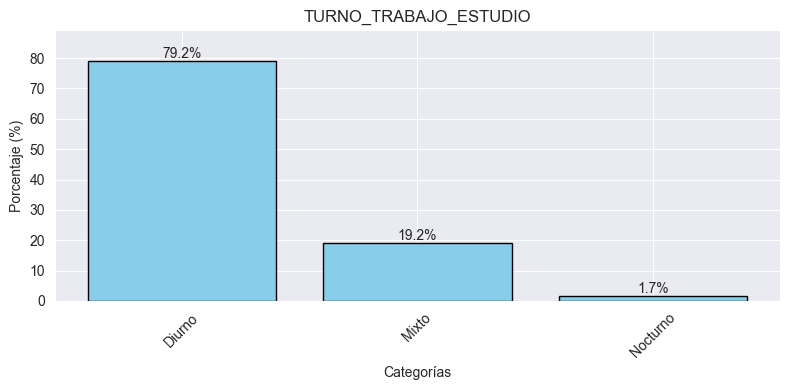

In [45]:
plot_categorical_summary(df_caracterizacion,'TURNO_TRABAJO_ESTUDIO')

In [46]:
df_caracterizacion['TURNO_TRABAJO_ESTUDIO'].value_counts()

TURNO_TRABAJO_ESTUDIO
Diurno      657
Mixto       159
Nocturno     14
Name: count, dtype: int64

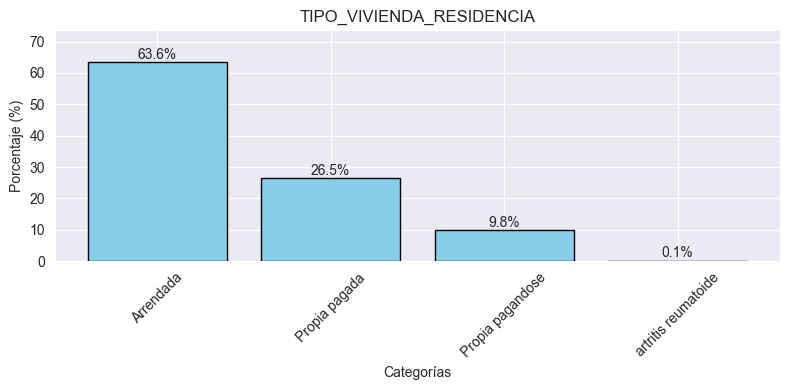

In [47]:
plot_categorical_summary(df_caracterizacion,'TIPO_VIVIENDA_RESIDENCIA')

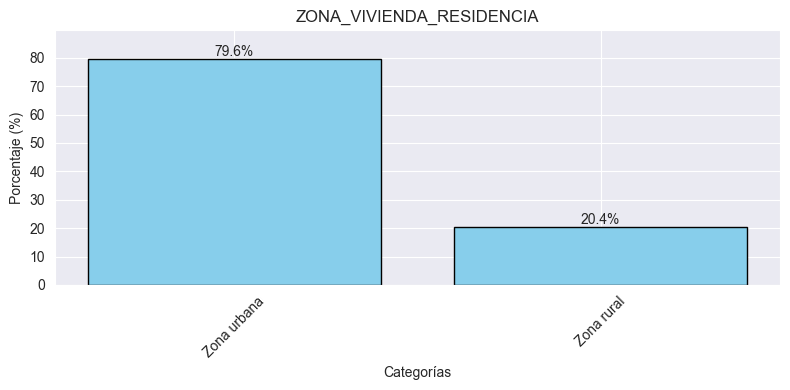

In [48]:
plot_categorical_summary(df_caracterizacion,'ZONA_VIVIENDA_RESIDENCIA')

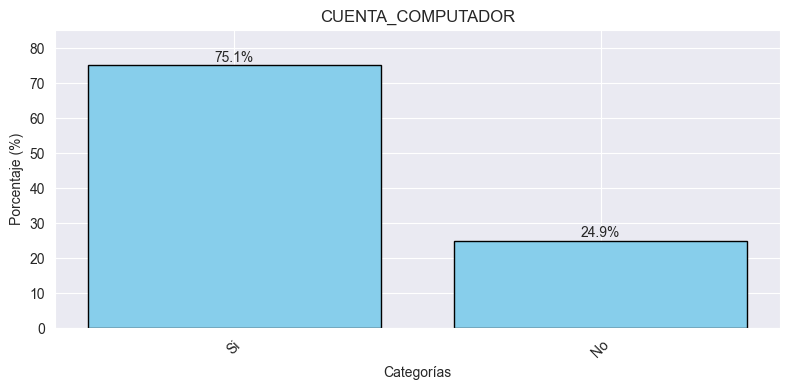

In [49]:
plot_categorical_summary(df_caracterizacion,'CUENTA_COMPUTADOR')


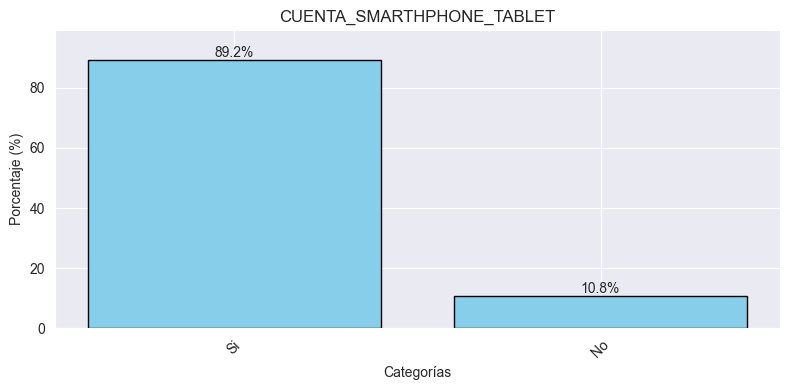

In [50]:
plot_categorical_summary(df_caracterizacion,'CUENTA_SMARTHPHONE_TABLET')

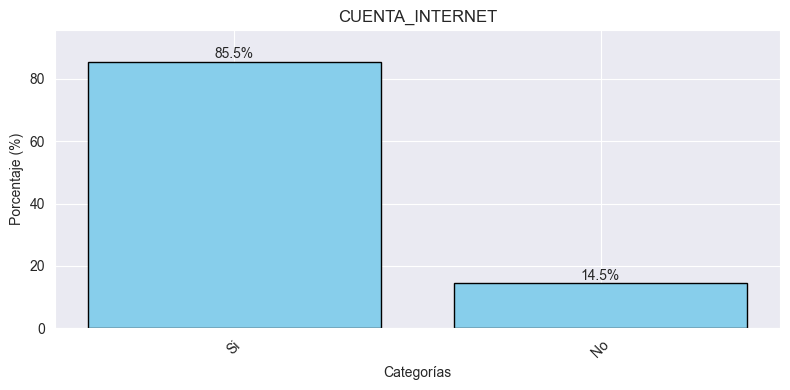

In [51]:
plot_categorical_summary(df_caracterizacion,'CUENTA_INTERNET')

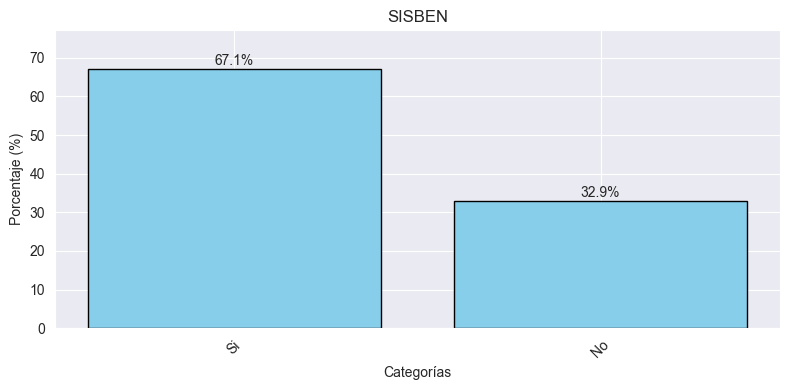

In [52]:
plot_categorical_summary(df_caracterizacion,'SISBEN')


In [53]:
df_caracterizacion['EPS'].value_counts()

EPS
Famisanar              133
famisanar               80
Sanitas                 71
sanitas                 43
Nueva EPS               42
                      ... 
Servisalud San Jose      1
famisanarFamisanar       1
COMPENSAR SALUD          1
Famisnar                 1
sanias                   1
Name: count, Length: 147, dtype: int64

se decide eliminar la variable EPS ya que se considera que la variable SISBEN y TIPO_USUARIO_EPS brindan igual o mejor información que EPS

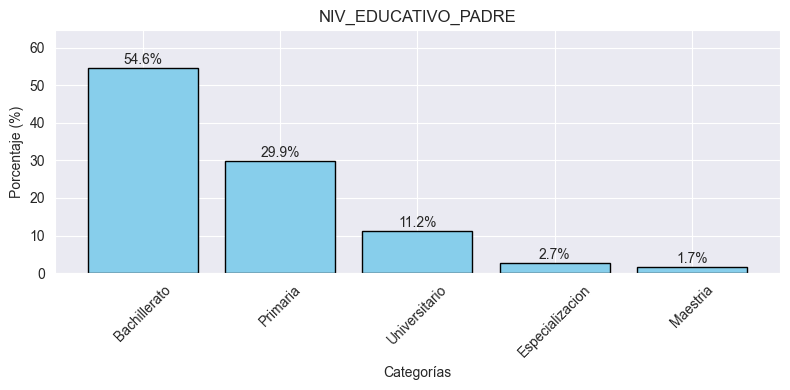

In [54]:
plot_categorical_summary(df_caracterizacion,'NIV_EDUCATIVO_PADRE')


In [55]:
def agrupar_nivel(nivel):
    if nivel in ['Primaria']:
        return 'Básica'
    elif nivel in ['Bachillerato']:
        return 'Media'
    else:
        return 'Superior'

df_caracterizacion['NIV_EDUCATIVO_PADRE_CAT'] = df_caracterizacion['NIV_EDUCATIVO_PADRE'].apply(agrupar_nivel)

C:\Users\User\AppData\Local\Temp\ipykernel_24440\427981655.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['NIV_EDUCATIVO_PADRE_CAT'] = df_caracterizacion['NIV_EDUCATIVO_PADRE'].apply(agrupar_nivel)


In [56]:
df_caracterizacion['NIV_EDUCATIVO_PADRE_CAT'].value_counts()

NIV_EDUCATIVO_PADRE_CAT
Media       453
Básica      248
Superior    129
Name: count, dtype: int64

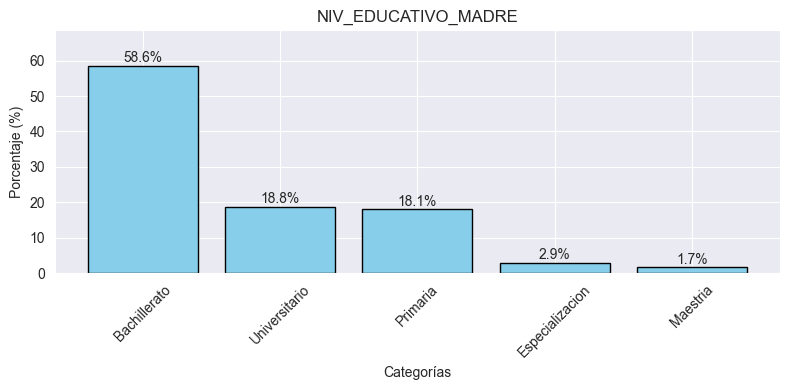

In [57]:
plot_categorical_summary(df_caracterizacion,'NIV_EDUCATIVO_MADRE')

C:\Users\User\AppData\Local\Temp\ipykernel_24440\1330150647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['NIV_EDUCATIVO_MADRE_CAT'] = df_caracterizacion['NIV_EDUCATIVO_MADRE'].apply(agrupar_nivel)


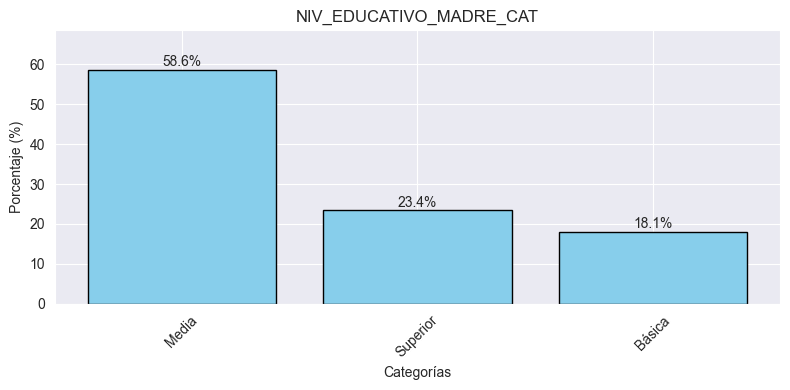

In [58]:
df_caracterizacion['NIV_EDUCATIVO_MADRE_CAT'] = df_caracterizacion['NIV_EDUCATIVO_MADRE'].apply(agrupar_nivel)
plot_categorical_summary(df_caracterizacion, 'NIV_EDUCATIVO_MADRE_CAT')

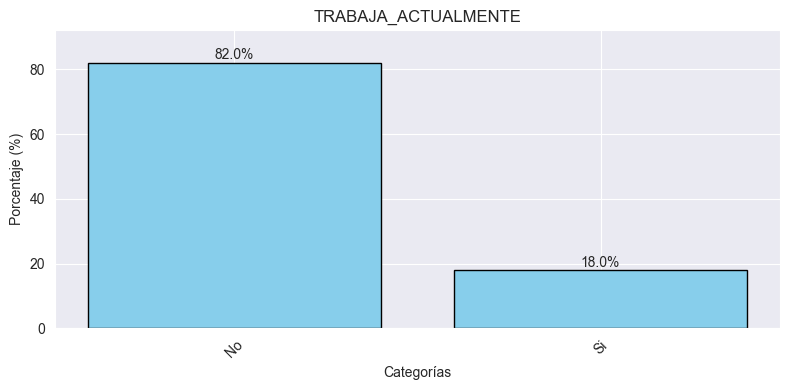

In [59]:
plot_categorical_summary(df_caracterizacion,'TRABAJA_ACTUALMENTE')

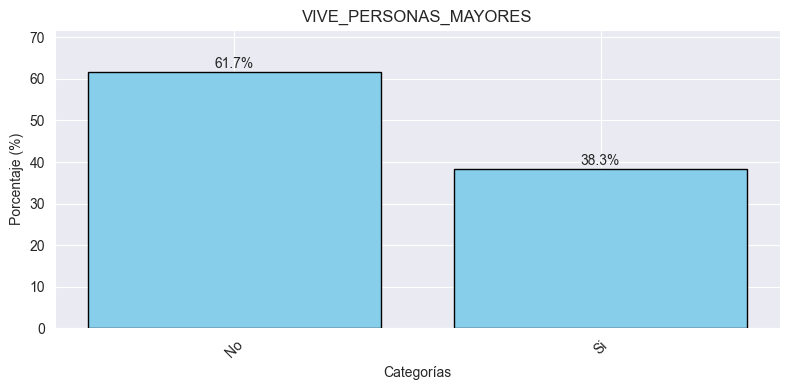

In [60]:
plot_categorical_summary(df_caracterizacion,'VIVE_PERSONAS_MAYORES')

In [61]:

# Limpieza básica: convertimos NaN a 'No reporta'
df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'] = df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'].fillna('No reporta')

# Variable binaria: vive o no con personas con patologías
df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'] = df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'].apply(
    lambda x: 'Sí' if x not in ['No reporta', 'Ninguna'] else 'No'
)

C:\Users\User\AppData\Local\Temp\ipykernel_24440\461450971.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'] = df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'].fillna('No reporta')
C:\Users\User\AppData\Local\Temp\ipykernel_24440\461450971.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'] = df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'].apply(


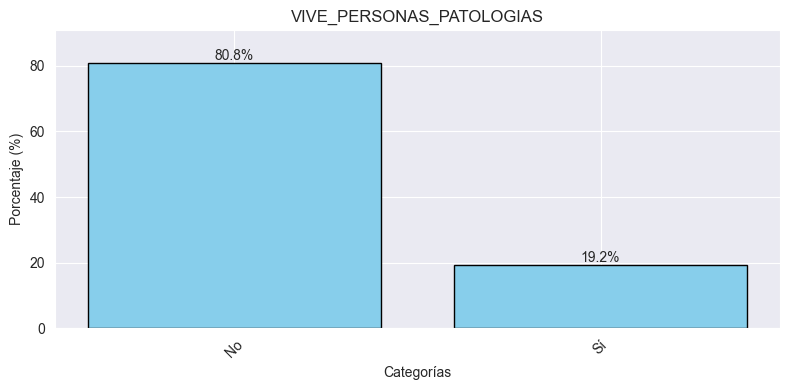

In [116]:
plot_categorical_summary(df_caracterizacion,'VIVE_PERSONAS_PATOLOGIAS')


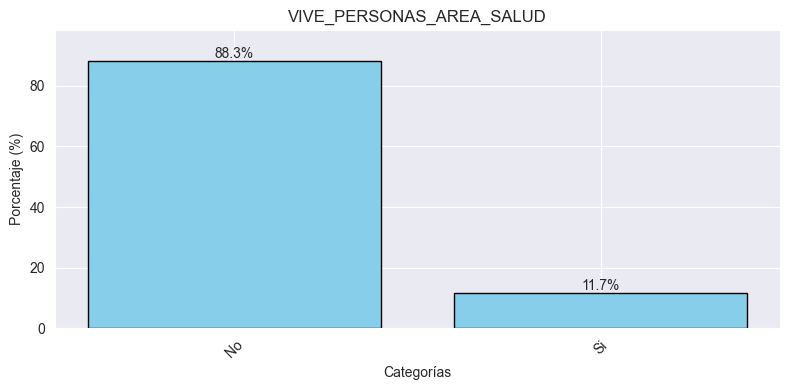

In [62]:
plot_categorical_summary(df_caracterizacion,'VIVE_PERSONAS_AREA_SALUD')


In [63]:
df_caracterizacion['ES_VULNERABLE'] = df_caracterizacion['GRUPO_POBLACION_VULNERABLE'].apply(
    lambda x: 'Sí' if pd.notnull(x) else 'No')

df_caracterizacion['GRUPO_POBLACION_VULNERABLE'] = df_caracterizacion['GRUPO_POBLACION_VULNERABLE'].fillna('No reportado')


C:\Users\User\AppData\Local\Temp\ipykernel_24440\2992585874.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['ES_VULNERABLE'] = df_caracterizacion['GRUPO_POBLACION_VULNERABLE'].apply(
C:\Users\User\AppData\Local\Temp\ipykernel_24440\2992585874.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['GRUPO_POBLACION_VULNERABLE'] = df_caracterizacion['GRUPO_POBLACION_VULNERABLE'].fillna('No reportado')


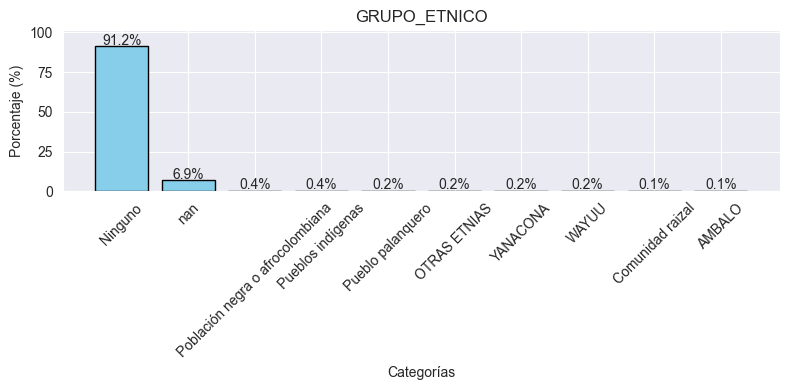

In [64]:
plot_categorical_summary(df_caracterizacion,'GRUPO_ETNICO')


In [65]:
df_caracterizacion['ES_GRUPO_ETNICO'] = df_caracterizacion['GRUPO_ETNICO'].apply(
    lambda x: 'Sí' if x != 'Ninguno' and pd.notnull(x) else 'No'
)

C:\Users\User\AppData\Local\Temp\ipykernel_24440\1403990048.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['ES_GRUPO_ETNICO'] = df_caracterizacion['GRUPO_ETNICO'].apply(


In [66]:
df_caracterizacion['GRUPO_ETNICO_CAT'] = df_caracterizacion['GRUPO_ETNICO'].replace({
    'Pueblos indígenas': 'Étnico',
    'Población negra o afrocolombiana': 'Étnico',
    'Comunidad raizal': 'Étnico',
    'Pueblo palanquero': 'Étnico',
    'Ninguno': 'No étnico',
    'OTRAS ETNIAS': 'Étnico',
    'WAYUU': 'Étnico',
    'YANACONA': 'Étnico',
    'AMBALO': 'Étnico'
}).fillna('No reportado')

C:\Users\User\AppData\Local\Temp\ipykernel_24440\4141498255.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['GRUPO_ETNICO_CAT'] = df_caracterizacion['GRUPO_ETNICO'].replace({


In [67]:
df_caracterizacion['GRUPO_ETNICO_CAT'].value_counts()

GRUPO_ETNICO_CAT
No étnico       757
No reportado     57
Étnico           16
Name: count, dtype: int64

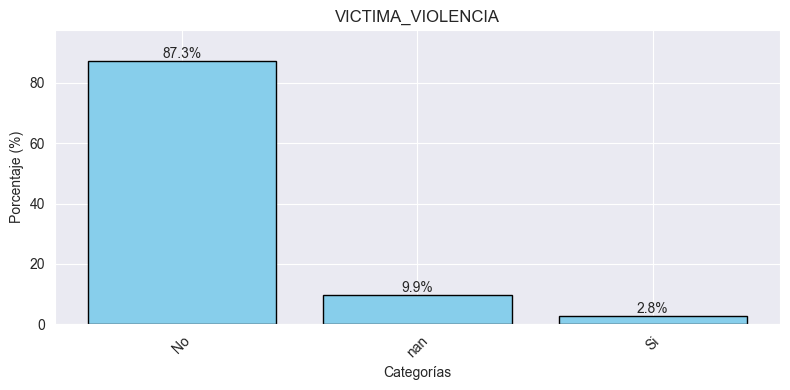

In [68]:
plot_categorical_summary(df_caracterizacion,'VICTIMA_VIOLENCIA')

In [69]:
'TIPO_DOCUMENTO', 'ORIENTACION_SEXUAL','EPS', 'NIV_EDUCATIVO_PADRE', 'NIV_EDUCATIVO_MADRE', 'GRUPO_POBLACION_VULNERABLE', 'GRUPO_ETNICO'

('TIPO_DOCUMENTO',
 'ORIENTACION_SEXUAL',
 'EPS',
 'NIV_EDUCATIVO_PADRE',
 'NIV_EDUCATIVO_MADRE',
 'GRUPO_POBLACION_VULNERABLE',
 'GRUPO_ETNICO')

In [71]:
df_caracterizacion['NIV_EDUCATIVO_PADRE'].value_counts()

NIV_EDUCATIVO_PADRE
Bachillerato       453
Primaria           248
Universitario       93
Especializacion     22
Maestria            14
Name: count, dtype: int64

In [72]:
df_caracterizacion['NIV_EDUCATIVO_PADRE_CAT'].value_counts()


NIV_EDUCATIVO_PADRE_CAT
Media       453
Básica      248
Superior    129
Name: count, dtype: int64

In [73]:
df_caracterizacion = df_caracterizacion.drop(columns=[
    'TIPO_DOCUMENTO', 'ORIENTACION_SEXUAL','EPS', 'NIV_EDUCATIVO_PADRE', 'NIV_EDUCATIVO_MADRE', 'GRUPO_POBLACION_VULNERABLE', 'GRUPO_ETNICO', 'FECHA_ACTUALIZACION'
])


In [75]:
df_caracterizacion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 830 entries, 4 to 2375
Data columns (total 66 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   DOCUMENTO                           830 non-null    int64  
 1   GENERO                              830 non-null    object 
 2   UBICACION_SEMESTRAL                 830 non-null    int64  
 3   MEDIO_TRANSPORTE                    830 non-null    object 
 4   FRECUENCIA_TRANSPORTE               830 non-null    object 
 5   HORARIO_INICIO_TRANSPORTE           830 non-null    object 
 6   HORARIO_FIN_TRANSPORTE              830 non-null    object 
 7   FUENTES_FINANCIACION                830 non-null    object 
 8   PERSONAS_A_CARGO                    830 non-null    float64
 9   DIFICULTAD_PAGO_MATRICULA           830 non-null    object 
 10  BARRIO_PUNTO_PARTIDA                830 non-null    object 
 11  TURNO_TRABAJO_ESTUDIO               830 non-null 

In [78]:
# Cambia el nombre de archivo según tu cambio
df_caracterizacion.to_excel("../data/df_caracterizacion_recategorizacion_variables.xlsx", index=False)